# Experiment 1.3.10 — Fixed250+Linear vs stacked-bin SNN ablation

Analysis-only notebook for the bounded-dynamics rerun. The primary baseline is **Fixed250 + Linear**. The trainable-dynamics condition now uses a bounded physical synaptic time constant, with `tau_syn` constrained to 20–300 ms and initialized from the original shift-derived values.

In [24]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
EXPERIMENT_ID = 'experiment_1_3_10_stacked_bin_snn_ablation'
PROTOCOL_VERSION = 'stacked250_v2_bounded_tau_syn'
LABELS = tuple(sorted(('A','B','C','D','E','X','G','H','I','J','K','L')))
LABEL_TAG = 'labels_' + '-'.join(LABELS)
RESULTS_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / EXPERIMENT_ID / PROTOCOL_VERSION / LABEL_TAG
RUNS_DIR = RESULTS_DIR / 'runs'
HISTORIES_DIR = RESULTS_DIR / 'histories'
BASELINE_DIR = RESULTS_DIR / 'baselines'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_SEEDS = (11,23,101)
ARCHITECTURES = ('1h128','1h256','1h512','1h1024','2h128')
OBJECTIVES = ('whole_count_ce','timestep_ce')
TRAIN_REGIMES = ('weight_only','trainable_dynamics')
EXPECTED_RUNS = 60
EXPECTED_BASELINES = 3
print('Results:', RESULTS_DIR)

Results: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_1_3_10_stacked_bin_snn_ablation/stacked250_v2_bounded_tau_syn/labels_A-B-C-D-E-G-H-I-J-K-L-X


## Load artifacts and verify pairing

In [25]:
def flatten_run(p):
    row = {
        'run_key': p['run_key'], 'split_seed': int(p['split_seed']),
        'architecture': p['architecture'], 'objective': p['objective'],
        'train_regime': p['train_regime'], 'best_epoch': int(p['best_epoch']),
        'sample_hash': p['sample_hash'], 'history_file': p['history_file'],
        'test_balanced_accuracy': float(p['metrics']['test']['balanced_accuracy']),
        'val_balanced_accuracy': float(p['metrics']['val']['balanced_accuracy']),
    }
    bounds = p['best_dynamics'].get('tau_syn_bounds_ms')
    if bounds:
        row['tau_syn_min_ms'] = float(bounds['min'])
        row['tau_syn_max_ms'] = float(bounds['max'])
    for h in p['best_dynamics']['hidden']:
        row[f"{h['layer']}_tau_syn_mean_ms"] = float(h['tau_syn_ms']['mean'])
        row[f"{h['layer']}_tau_syn_min_ms"] = float(h['tau_syn_ms']['min'])
        row[f"{h['layer']}_tau_syn_max_ms"] = float(h['tau_syn_ms']['max'])
    return row

def flatten_baseline(p):
    return {
        'baseline_id': p['baseline_id'], 'split_seed': int(p['split_seed']),
        'sample_hash': p['sample_hash'],
        'test_balanced_accuracy': float(p['metrics']['test']['balanced_accuracy'])
    }

run_files = sorted(RUNS_DIR.glob('run_*.json')) if RUNS_DIR.exists() else []
payloads = [json.loads(path.read_text()) for path in run_files]
runs = pd.DataFrame(flatten_run(p) for p in payloads)
baseline_files = sorted(BASELINE_DIR.glob('fixed250_count_linear_split*.json')) if BASELINE_DIR.exists() else []
baseline_payloads = [json.loads(path.read_text()) for path in baseline_files]
baseline = pd.DataFrame(flatten_baseline(p) for p in baseline_payloads)
print(f'SNN completed: {len(runs)}/{EXPECTED_RUNS}')
print(f'Fixed250+Linear completed: {len(baseline)}/{EXPECTED_BASELINES}')
if not runs.empty:
    assert (runs.groupby('split_seed').sample_hash.nunique() == 1).all()
if len(baseline) == EXPECTED_BASELINES and not runs.empty:
    snn_hash = runs.groupby('split_seed', as_index=False).sample_hash.first().rename(columns={'sample_hash':'snn_sample_hash'})
    paired_hash = baseline.merge(snn_hash, on='split_seed', how='inner')
    assert len(paired_hash) == EXPECTED_BASELINES
    assert (paired_hash.sample_hash == paired_hash.snn_sample_hash).all(), 'Baseline/SNN sample pairing failed'
display(runs.head())
display(baseline)

SNN completed: 60/60
Fixed250+Linear completed: 3/3


,run_key,split_seed,architecture,objective,train_regime,best_epoch,sample_hash,history_file,test_balanced_accuracy,val_balanced_accuracy,tau_syn_min_ms,tau_syn_max_ms,hidden_1_tau_syn_mean_ms,hidden_1_tau_syn_min_ms,hidden_1_tau_syn_max_ms,hidden_2_tau_syn_mean_ms,hidden_2_tau_syn_min_ms,hidden_2_tau_syn_max_ms
0,split101__1h1024__timestep_ce__trainable_dynamics,101,1h1024,timestep_ce,trainable_dynamics,63,904364bb02dc65c5d226b35e9acf226599682e62533d02...,notebooks/artifacts/experiment_1_3_10_stacked_...,0.521917,0.618544,20.0,300.0,140.303262,54.616596,248.956451,NaN,NaN,NaN
1,split101__1h1024__timestep_ce__weight_only,101,1h1024,timestep_ce,weight_only,92,904364bb02dc65c5d226b35e9acf226599682e62533d02...,notebooks/artifacts/experiment_1_3_10_stacked_...,0.604976,0.652581,20.0,300.0,137.728655,54.313430,242.103471,NaN,NaN,NaN
2,split101__1h1024__whole_count_ce__trainable_dy...,101,1h1024,whole_count_ce,trainable_dynamics,34,904364bb02dc65c5d226b35e9acf226599682e62533d02...,notebooks/artifacts/experiment_1_3_10_stacked_...,0.572749,0.629735,20.0,300.0,139.577784,54.321629,247.823792,NaN,NaN,NaN
3,split101__1h1024__whole_count_ce__weight_only,101,1h1024,whole_count_ce,weight_only,32,904364bb02dc65c5d226b35e9acf226599682e62533d02...,notebooks/artifacts/experiment_1_3_10_stacked_...,0.592613,0.616173,20.0,300.0,137.728655,54.313430,242.103471,NaN,NaN,NaN
4,split101__1h128__timestep_ce__trainable_dynamics,101,1h128,timestep_ce,trainable_dynamics,40,904364bb02dc65c5d226b35e9acf226599682e62533d02...,notebooks/artifacts/experiment_1_3_10_stacked_...,0.596558,0.607730,20.0,300.0,141.498390,55.458996,248.082001,NaN,NaN,NaN


,baseline_id,split_seed,sample_hash,test_balanced_accuracy
0,fixed250_count_linear,101,904364bb02dc65c5d226b35e9acf226599682e62533d02...,0.659180
1,fixed250_count_linear,11,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,0.683184
2,fixed250_count_linear,23,85d14b124241660c22126d21cff9471c44f1adeea642df...,0.537563


## Fixed250+Linear vs SNN and paired delta

,architecture,train_regime,objective,mean_test_ba,sd_test_ba
15,1h512,weight_only,whole_count_ce,0.615138,0.062606
10,1h256,weight_only,timestep_ce,0.608934,0.078046
14,1h512,weight_only,timestep_ce,0.606962,0.078273
13,1h512,trainable_dynamics,whole_count_ce,0.604821,0.052923
2,1h1024,weight_only,timestep_ce,0.601867,0.084113
4,1h128,trainable_dynamics,timestep_ce,0.597045,0.060631
11,1h256,weight_only,whole_count_ce,0.595533,0.105477
6,1h128,weight_only,timestep_ce,0.589594,0.092336
3,1h1024,weight_only,whole_count_ce,0.587902,0.090982
8,1h256,trainable_dynamics,timestep_ce,0.584892,0.066513


,architecture,train_regime,objective,mean_delta_ba,sd_delta_ba,mean_snn_test_ba,mean_baseline_test_ba
15,1h512,weight_only,whole_count_ce,-0.011504,0.052880,0.615138,0.626642
10,1h256,weight_only,timestep_ce,-0.017708,0.047064,0.608934,0.626642
14,1h512,weight_only,timestep_ce,-0.019680,0.051265,0.606962,0.626642
13,1h512,trainable_dynamics,whole_count_ce,-0.021822,0.035247,0.604821,0.626642
2,1h1024,weight_only,timestep_ce,-0.024776,0.027863,0.601867,0.626642
4,1h128,trainable_dynamics,timestep_ce,-0.029597,0.031086,0.597045,0.626642
11,1h256,weight_only,whole_count_ce,-0.031109,0.063481,0.595533,0.626642
6,1h128,weight_only,timestep_ce,-0.037048,0.063690,0.589594,0.626642
3,1h1024,weight_only,whole_count_ce,-0.038741,0.030127,0.587902,0.626642
8,1h256,trainable_dynamics,timestep_ce,-0.041751,0.041212,0.584892,0.626642


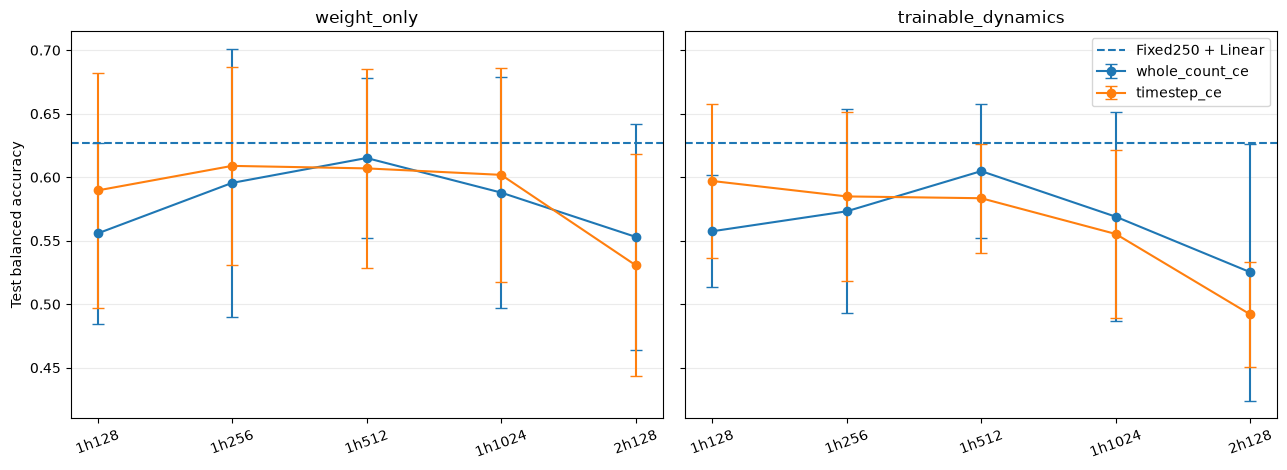

In [26]:
summary = pd.DataFrame()
paired_summary = pd.DataFrame()
if not runs.empty:
    summary = (runs.groupby(['architecture','train_regime','objective'], as_index=False)
        .agg(mean_test_ba=('test_balanced_accuracy','mean'), sd_test_ba=('test_balanced_accuracy','std')))
    display(summary.sort_values('mean_test_ba', ascending=False))

if not runs.empty and len(baseline) == EXPECTED_BASELINES:
    paired = runs.merge(
        baseline[['split_seed','test_balanced_accuracy']].rename(columns={'test_balanced_accuracy':'baseline_test_ba'}),
        on='split_seed', how='inner')
    paired['delta_vs_fixed250_linear'] = paired.test_balanced_accuracy - paired.baseline_test_ba
    paired_summary = (paired.groupby(['architecture','train_regime','objective'], as_index=False)
        .agg(mean_delta_ba=('delta_vs_fixed250_linear','mean'), sd_delta_ba=('delta_vs_fixed250_linear','std'),
             mean_snn_test_ba=('test_balanced_accuracy','mean'), mean_baseline_test_ba=('baseline_test_ba','mean')))
    display(paired_summary.sort_values('mean_delta_ba', ascending=False))
    paired.to_csv(RESULTS_DIR/'paired_snn_vs_fixed250_linear.csv', index=False)
    paired_summary.to_csv(RESULTS_DIR/'paired_snn_vs_fixed250_linear_summary.csv', index=False)

if not summary.empty:
    x = np.arange(len(ARCHITECTURES))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    baseline_mean = baseline.test_balanced_accuracy.mean() if not baseline.empty else np.nan
    for ax, regime in zip(axes, TRAIN_REGIMES):
        for objective in OBJECTIVES:
            p = summary[(summary.train_regime==regime)&(summary.objective==objective)].set_index('architecture').reindex(ARCHITECTURES)
            ax.errorbar(x, p.mean_test_ba, yerr=p.sd_test_ba.fillna(0), marker='o', capsize=4, label=objective)
        if np.isfinite(baseline_mean): ax.axhline(baseline_mean, linestyle='--', label='Fixed250 + Linear')
        ax.set_xticks(x, ARCHITECTURES, rotation=20); ax.set_title(regime); ax.grid(axis='y', alpha=.25)
    axes[0].set_ylabel('Test balanced accuracy'); axes[1].legend(); fig.tight_layout(); plt.show()

## Train objective loss vs epoch

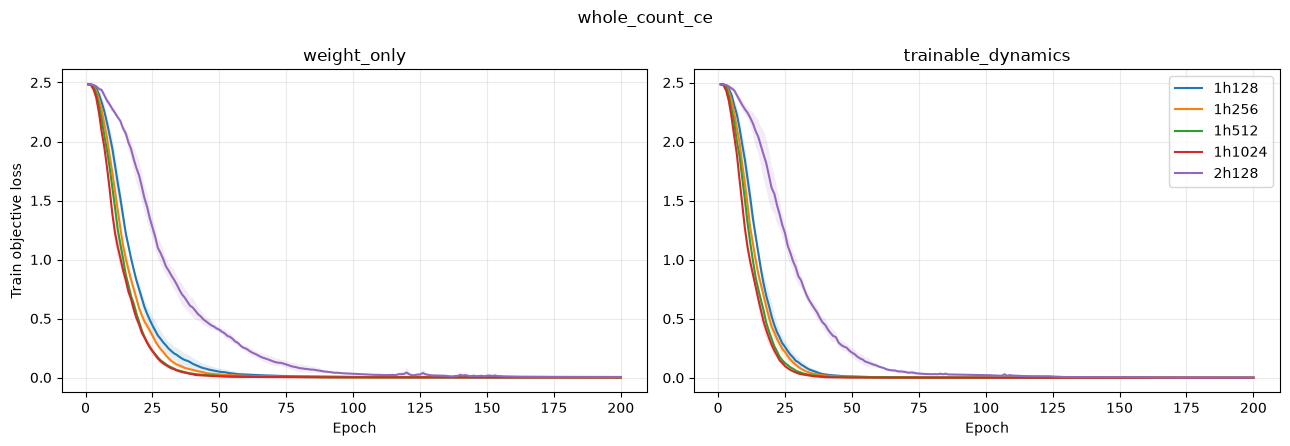

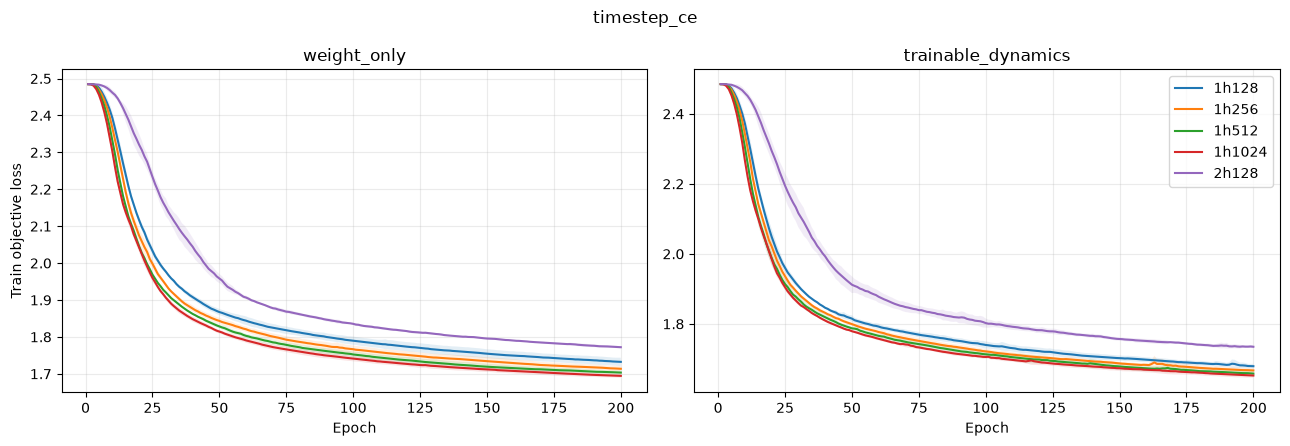

In [27]:
history_parts = []
for p in payloads:
    history_path = REPO_ROOT / p['history_file']
    if not history_path.exists(): continue
    h = pd.read_csv(history_path)
    h['split_seed'] = int(p['split_seed']); h['architecture'] = p['architecture']
    h['objective'] = p['objective']; h['train_regime'] = p['train_regime']
    history_parts.append(h)
history = pd.concat(history_parts, ignore_index=True) if history_parts else pd.DataFrame()
if not history.empty:
    loss_summary = (history.groupby(['epoch','architecture','objective','train_regime'], as_index=False)
        .agg(mean_train_objective_loss=('train_objective_loss','mean'), sd_train_objective_loss=('train_objective_loss','std')))
    loss_summary.to_csv(RESULTS_DIR/'train_loss_by_epoch_summary.csv', index=False)
    for objective in OBJECTIVES:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
        for ax, regime in zip(axes, TRAIN_REGIMES):
            for architecture in ARCHITECTURES:
                p = loss_summary[(loss_summary.objective==objective)&(loss_summary.train_regime==regime)&(loss_summary.architecture==architecture)]
                if p.empty: continue
                ax.plot(p.epoch, p.mean_train_objective_loss, label=architecture)
                sd = p.sd_train_objective_loss.fillna(0)
                ax.fill_between(p.epoch, p.mean_train_objective_loss-sd, p.mean_train_objective_loss+sd, alpha=.12)
            ax.set_title(regime); ax.set_xlabel('Epoch'); ax.grid(alpha=.25)
        axes[0].set_ylabel('Train objective loss'); axes[1].legend(); fig.suptitle(objective); fig.tight_layout(); plt.show()

## Bounded tau_syn sanity check

In [28]:
if not runs.empty:
    bounded = runs[runs.train_regime=='trainable_dynamics'].copy()
    if not bounded.empty:
        assert (bounded.tau_syn_min_ms == 20.0).all()
        assert (bounded.tau_syn_max_ms == 300.0).all()
        tau_cols = [c for c in bounded.columns if c.endswith('_tau_syn_mean_ms')]
        for c in tau_cols:
            values = bounded[c].dropna()
            assert ((values > 20.0) & (values < 300.0)).all(), f'Out-of-range tau_syn in {c}'
        display(bounded[['architecture','objective','split_seed',*tau_cols]].sort_values(['architecture','objective','split_seed']))

,architecture,objective,split_seed,hidden_1_tau_syn_mean_ms,hidden_2_tau_syn_mean_ms
20,1h1024,timestep_ce,11,139.899581,NaN
40,1h1024,timestep_ce,23,140.300019,NaN
0,1h1024,timestep_ce,101,140.303262,NaN
22,1h1024,whole_count_ce,11,139.659038,NaN
42,1h1024,whole_count_ce,23,139.583740,NaN
2,1h1024,whole_count_ce,101,139.577784,NaN
24,1h128,timestep_ce,11,141.195590,NaN
44,1h128,timestep_ce,23,141.632375,NaN
4,1h128,timestep_ce,101,141.498390,NaN
26,1h128,whole_count_ce,11,140.422154,NaN
